In [1]:
import benchmark
import numpy as np
import json
from joblib import Parallel, delayed
from tqdm_joblib import tqdm_joblib
import matplotlib.pyplot as plt

/home/mulkr/base/lib/python3.11/site-packages/tqdm_joblib/__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
TOL = 0.03 # tolerance value used for accuracy metrics
HR_WIN = 10 # time window in secods to calculate heart rate
HR_WIN_OVERLAP = 0.5 # heart rate window overlap percentage
HR_RANGE = (100,210) # range of acceptable heart rates
JOBS = 4 # evaluation jobs to run in parallel

In [3]:
# Ground truth
GT = benchmark.get_detections("../top50/top50label")
gt_m = benchmark.method("GroundTruth",*GT)
gt_m.calc_HR(HR_WIN,HR_WIN_OVERLAP,HR_RANGE)

[[132.365188986896,
  134.43339506480746,
  134.43339506480746,
  134.4333950648385,
  134.43339506480746,
  133.5984050333533,
  136.56725847853727,
  136.56725847853838,
  135.066519374394,
  133.59840503335434,
  133.54586779480633],
 [133.63990811041398,
  129.1852445067339,
  123.68800005963192,
  125.01797855488239,
  125.69375141194904,
  125.69375141193593,
  125.01797855489673,
  125.01797855490922,
  125.0179785549083,
  130.63676410793423,
  141.7886829951884],
 [128.0769230769227,
  128.0769230769228,
  128.9032258064418,
  130.5882352941055,
  130.58823529413374,
  133.20000000001582,
  133.20000000001582,
  133.20000000001372,
  132.3178807947179,
  130.58823529413374,
  128.90322580644232],
 [135.45762711864492,
  133.20000000000005,
  128.90322580644232,
  137.79310344828772,
  144.7826086956577,
  145.83941605839811,
  143.22580645160306,
  140.70422535210406,
  137.3195876288768,
  135.00000000001344,
  146.3736263736289],
 [135.91836734693922,
  138.7500000000054,
  

In [4]:
# Load methods for testing
# Make sure the detections are in the correct folder and use the pyPCG format
current_methods = [
    benchmark.method("Chen (2006)*",*benchmark.get_detections("/home/mulkr/PhD/fpcg-gen/testing/chen")),
    benchmark.method("Schmidt (2010)",*benchmark.get_detections("/home/mulkr/PhD/fpcg-gen/testing/schmidt")), # External: use MATLAB for Schmidt method
    benchmark.method("Balogh (2011)*",*benchmark.get_detections("/home/mulkr/PhD/fpcg-gen/testing/balogh")),
    benchmark.method("Cesarelli (2012)*",*benchmark.get_detections("/home/mulkr/PhD/fpcg-gen/testing/cesarelli")),
    benchmark.method("Springer (2016)",*benchmark.get_detections("/home/mulkr/PhD/fpcg-gen/testing/springer")), # External: use MATLAB for Springer method
    benchmark.method("Renna-Seqmax (2019)*",*benchmark.get_detections("/home/mulkr/PhD/fpcg-gen/testing/renna_seqmax")),
    benchmark.method("Renna-HSMM (2019)*",*benchmark.get_detections("/home/mulkr/PhD/fpcg-gen/testing/renna_hsmm")),
    benchmark.method("Müller (2024)",*benchmark.get_detections("/home/mulkr/PhD/fpcg-gen/testing/muller")),
]


In [5]:
# Load Tang et al. FHR
tang = benchmark.method("Tang (2016)")
with open("/home/mulkr/PhD/fpcg-gen/eval/tang_fhr.json","r") as tang_hr:
    hrs = json.loads(tang_hr.read())
    for hr in hrs.values():
        tang.HR.append(hr)

# Load Zahorian et al. FHR
zahorian = benchmark.method("Zahorian (2012)*")
with open("/home/mulkr/PhD/fpcg-gen/eval/zahorian_fhr.json","r") as zahorian_hr:
    hrs = json.loads(zahorian_hr.read())
    for hr in hrs.values():
        zahorian.HR.append(hr)

In [6]:
tolerances = np.arange(0.003,0.09,0.003)

In [7]:
def calc_measures(method):
    method.calc_HR(HR_WIN,HR_WIN_OVERLAP,HR_RANGE)
    method.calc_mae(GT)
    method.calc_tolerance_score(GT,tolerances)
    method.calc_error(GT,TOL)
    method.calc_hr_mse(gt_m.HR)
    return method

In [8]:
# Calculate measures
with tqdm_joblib(total=len(current_methods)):
    methods: list[benchmark.method] = Parallel(n_jobs=JOBS)(delayed(calc_measures)(m) for m in current_methods) # type: ignore

tang.calc_hr_mse(gt_m.HR)
zahorian.calc_hr_mse(gt_m.HR)

  0%|          | 0/8 [00:00<?, ?it/s]

[5.4329629760439255,
 12.052196360333886,
 8.959176187011808,
 4.769113329304201,
 1.2255504196338776,
 3.693719581745721,
 1.794080538712008,
 5.953543828461216,
 4.609806813105241,
 4.877090881076066,
 1.6884615503341431,
 11.90256880050512,
 4.4654467525905295,
 6.098539573975938,
 2.6639091845862777,
 2.82090731208186,
 8.193156185494106,
 3.8035191557157604,
 7.528059353270394,
 14.621040908839593,
 2.1641215186193534,
 1.7805833734212564,
 1.538539231688038,
 4.511563869240999,
 9.077872823579067,
 2.3791609900792783,
 1.2506602250609082,
 7.452192732512526,
 1.8995460220310334,
 2.224503750807385,
 2.127483552433582,
 6.3586491854245875,
 1.580900102362338,
 2.1259079063115163,
 2.4637318641996755,
 3.527840087341355,
 4.294035768919744,
 7.149760383090736,
 1.9949211782271628,
 7.519811837164386,
 5.261635184603051,
 4.993098148762535,
 0.8574893879409212,
 1.939156756500642,
 4.590761368231757,
 4.347933932518515,
 8.490151589187194,
 5.028731106186626,
 4.562453409279232,
 5.

In [9]:
def custom_lines():
    color_cycle = ['#377eb8', '#ff7f00', '#4daf4a', '#e41a1c']
    styles = ["-","--","-.",":"]
    for style in styles:
        for color in color_cycle:
            yield (style, color)

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


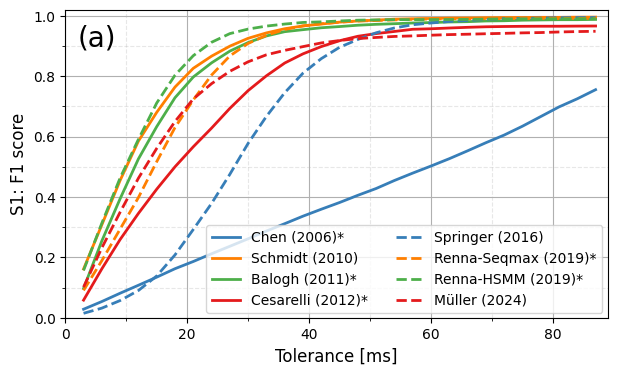

In [136]:
scores = [m.F1_1 for m in methods]
names = [m.name for m in methods]

plt.figure(figsize=(7,4))
lines = custom_lines()
for s in scores:
    style, color = next(lines)
    plt.plot(tolerances*1000,s,linestyle=style,color=color,linewidth=2)
plt.ylim((0,1.02))
ax = plt.gca()
ax.set_xticks(np.arange(0, tolerances[-1]*1000, 20))
ax.set_xticks(np.arange(0, tolerances[-1]*1000, 10), minor = True)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_yticks(np.arange(0, 1.1, 0.1), minor = True)
plt.grid(True,"both")
ax.grid(which="minor",alpha=0.3,linestyle="--")
plt.xlim((tolerances[0]*1000-3,tolerances[-1]*1000+2))
plt.xlabel("Tolerance [ms]",fontsize="large")
plt.ylabel("S1: F1 score",fontsize="large")
plt.text(2,0.9,"(a)",fontsize=20)
plt.legend(names,loc=(0.26,0.015),fontsize="medium",ncols=2)
plt.savefig("s1_f1.eps",bbox_inches="tight")
plt.show()

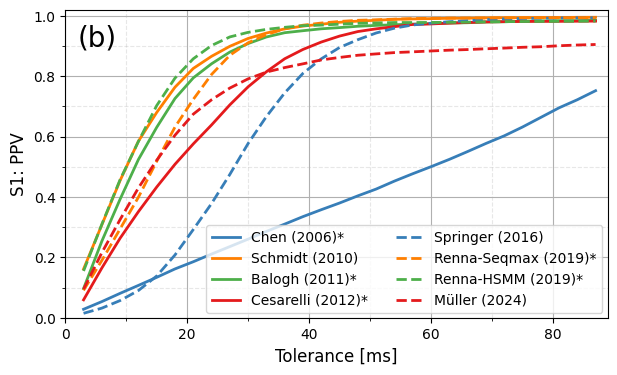

In [13]:
scores = [m.PPV_1 for m in methods]
names = [m.name for m in methods]

plt.figure(figsize=(7,4))
lines = custom_lines()
for s in scores:
    style, color = next(lines)
    plt.plot(tolerances*1000,s,linestyle=style,color=color,linewidth=2)
plt.ylim((0,1.02))
ax = plt.gca()
ax.set_xticks(np.arange(0, tolerances[-1]*1000, 20))
ax.set_xticks(np.arange(0, tolerances[-1]*1000, 10), minor = True)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_yticks(np.arange(0, 1.1, 0.1), minor = True)
plt.grid(True,"both")
ax.grid(which="minor",alpha=0.3,linestyle="--")
plt.xlim((tolerances[0]*1000-3,tolerances[-1]*1000+2))
plt.xlabel("Tolerance [ms]",fontsize="large")
plt.ylabel("S1: PPV",fontsize="large")
plt.text(2,0.9,"(b)",fontsize=20)
plt.legend(names,loc=(0.26,0.015),fontsize="medium",ncols=2)
# plt.savefig("s1_ppv.eps",bbox_inches="tight")
plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


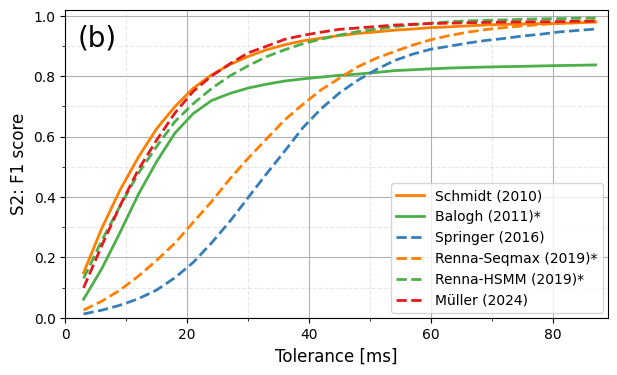

In [135]:
scores = [m.F1_2 for m in methods]
names = [m.name for m in methods]

plt.figure(figsize=(7,4))
lines = custom_lines()
filt_names = []
for s,n in zip(scores,names):
    style, color = next(lines)
    if n.startswith("Chen") or n.startswith("Cesarelli"):
        continue
    plt.plot(tolerances*1000,s,linestyle=style,color=color,linewidth=2)
    filt_names.append(n)
plt.ylim((0,1.02))
ax = plt.gca()
ax.set_xticks(np.arange(0, tolerances[-1]*1000, 20))
ax.set_xticks(np.arange(0, tolerances[-1]*1000, 10), minor = True)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_yticks(np.arange(0, 1.1, 0.1), minor = True)
plt.grid(True,"both")
ax.grid(which="minor",alpha=0.3,linestyle="--")
plt.xlim((tolerances[0]*1000-3,tolerances[-1]*1000+2))
plt.xlabel("Tolerance [ms]",fontsize="large")
plt.ylabel("S2: F1 score",fontsize="large")
# plt.text(2,0.9,"(a)",fontsize=20)
plt.legend(filt_names,loc=(0.6,0.015),fontsize="medium")
plt.text(2,0.9,"(b)",fontsize=20)
plt.savefig("s2_f1.eps",bbox_inches="tight")
plt.show()

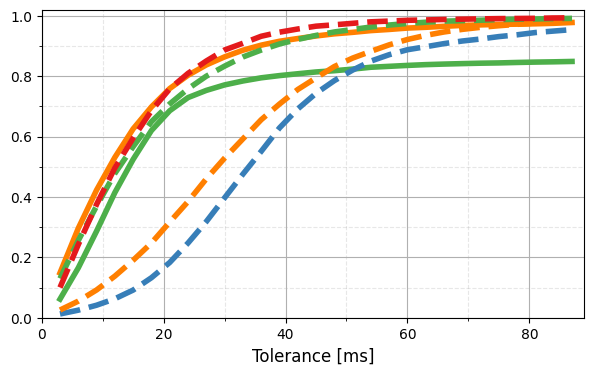

In [11]:
scores = [m.PPV_2 for m in methods]
names = [m.name for m in methods]

plt.figure(figsize=(7,4))
lines = custom_lines()
filt_names = []
for s,n in zip(scores,names):
    style, color = next(lines)
    if n.startswith("Chen") or n.startswith("Cesarelli"):
        continue
    plt.plot(tolerances*1000,s,linestyle=style,color=color,linewidth=4)
    filt_names.append(n)
plt.ylim((0,1.02))
ax = plt.gca()
ax.set_xticks(np.arange(0, tolerances[-1]*1000, 20))
ax.set_xticks(np.arange(0, tolerances[-1]*1000, 10), minor = True)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.set_yticks(np.arange(0, 1.1, 0.1), minor = True)
plt.grid(True,"both")
ax.grid(which="minor",alpha=0.3,linestyle="--")
plt.xlim((tolerances[0]*1000-3,tolerances[-1]*1000+2))
plt.xlabel("Tolerance [ms]",fontsize="large")
# plt.ylabel("S2: PPV",fontsize="large")
# plt.text(2,0.9,"(b)",fontsize=20)
# plt.legend(filt_names,loc=(0.6,0.015),fontsize="medium")
plt.savefig("s2_ppv.png",bbox_inches="tight")
plt.show()

In [12]:
from copy import copy

sum_methods = copy(methods)
# sum_methods.insert(5,tang)
# sum_methods.insert(3,zahorian)
sum_names = [m.name.replace(" ","\n") for m in sum_methods]
fhr_errors = [m.MSE_hr for m in sum_methods]
for method in sum_methods:
    temp = np.array(method.MSE_hr)
    print(method.name,"outliers:",np.count_nonzero(temp>2))
sum_names.pop(0)
fhr_errors.pop(0)
print("-")

Chen (2006)* outliers: 39
Schmidt (2010) outliers: 0
Balogh (2011)* outliers: 0
Cesarelli (2012)* outliers: 1
Springer (2016) outliers: 0
Renna-Seqmax (2019)* outliers: 1
Renna-HSMM (2019)* outliers: 0
Müller (2024) outliers: 1
-


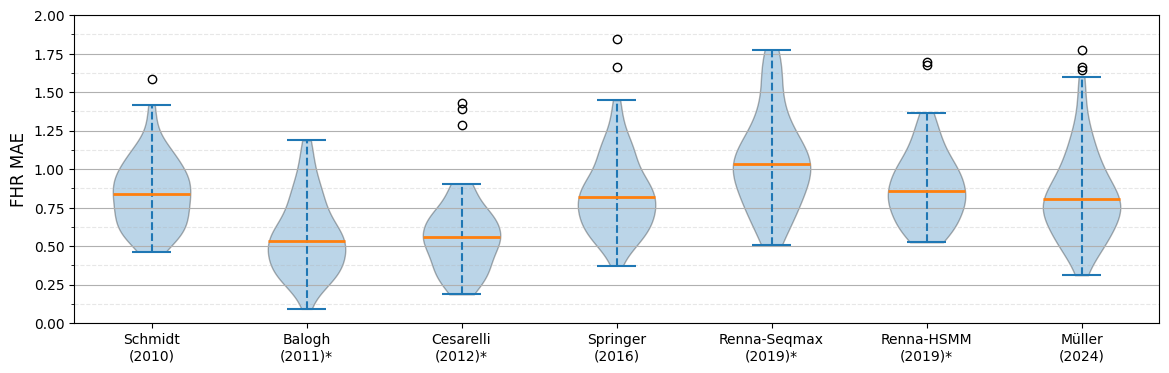

In [81]:
plt.figure(figsize=(14,4))
plt.boxplot(fhr_errors,showcaps=False,showbox=False,showmeans=False,medianprops=dict(linewidth="2"),whiskerprops=dict(linewidth="0"))
# plt.violinplot(fhr_errors,quantiles=np.tile([.25,.75],(1,len(fhr_errors))),showmeans=True)
parts = plt.violinplot([benchmark.rm_outliers(error) for error in fhr_errors])
# parts = plt.violinplot(fhr_errors)
plt.xticks(ticks=(np.arange(len(sum_names))+1),labels=sum_names)
plt.yticks(ticks=np.arange(0.125,2,0.25),minor=True)
plt.ylim((0,2))
plt.grid(True,axis="y",which="both")
ax = plt.gca()
ax.grid(which="minor",alpha=0.3,linestyle="--")
plt.ylabel("FHR MAE",fontsize="large")
# plt.xlabel("Method",fontsize="large")

for pc in parts['bodies']:
    pc.set_edgecolor("black")
parts['cbars'].set_linestyle("--")
plt.savefig("fhr_violin_1.pdf",bbox_inches="tight")
plt.show()

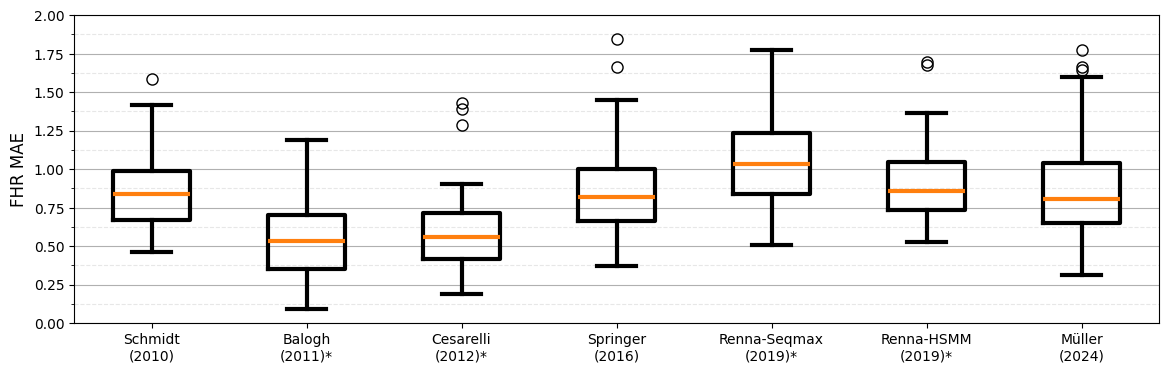

In [28]:
plt.figure(figsize=(14,4))
plt.boxplot(fhr_errors,showcaps=True,showbox=True,showmeans=False,medianprops=dict(linewidth="3"),whiskerprops=dict(linewidth="3"),capprops=dict(linewidth="3"),boxprops=dict(linewidth="3"),flierprops=dict(markersize="8"))
# plt.violinplot(fhr_errors,quantiles=np.tile([.25,.75],(1,len(fhr_errors))),showmeans=True)
# parts = plt.violinplot(fhr_errors)
plt.xticks(ticks=(np.arange(len(sum_names))+1),labels=sum_names)
plt.yticks(ticks=np.arange(0.125,2,0.25),minor=True)
plt.ylim((0,2))
plt.grid(True,axis="y",which="both")
ax = plt.gca()
ax.grid(which="minor",alpha=0.3,linestyle="--")
plt.ylabel("FHR MAE",fontsize="large")
# plt.xlabel("Method",fontsize="large")
plt.savefig("error.png",bbox_inches="tight")
plt.show()

In [24]:
parts["cmaxes"]

In [78]:
sum_methods = [methods[0], zahorian, tang]
sum_names = [m.name.replace(" ","\n") for m in sum_methods]
fhr_errors = [m.MSE_hr for m in sum_methods]
for method in sum_methods:
    temp = np.array(method.MSE_hr)
    print(method.name,"outliers:",np.count_nonzero(temp>15))
print("-")

Chen (2006)* outliers: 0
Zahorian (2012)* outliers: 0
Tang (2016) outliers: 0
-


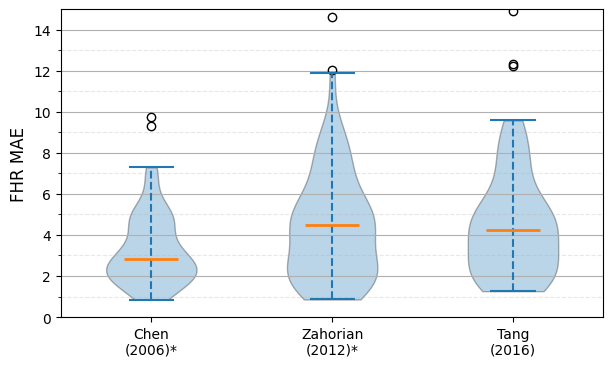

In [77]:
plt.figure(figsize=(7,4))
plt.boxplot(fhr_errors,showcaps=False,showbox=False,showmeans=False,medianprops=dict(linewidth="2"),whiskerprops=dict(linewidth="0"))
# plt.violinplot(fhr_errors,quantiles=np.tile([.25,.75],(1,len(fhr_errors))),showmeans=True)
parts = plt.violinplot([benchmark.rm_outliers(error) for error in fhr_errors])
# parts = plt.violinplot(fhr_errors)
plt.xticks(ticks=(np.arange(len(sum_names))+1),labels=sum_names)
plt.yticks(ticks=np.arange(1,15),minor=True)
plt.ylim((0,15))
plt.grid(True,axis="y",which="both")
ax = plt.gca()
ax.grid(which="minor",alpha=0.3,linestyle="--")
plt.ylabel("FHR MAE",fontsize="large")
# plt.xlabel("Method",fontsize="large")

for pc in parts['bodies']:
    pc.set_edgecolor("black")
parts['cbars'].set_linestyle("--")
plt.savefig("fhr_violin_2.pdf",bbox_inches="tight")
plt.show()

In [132]:
# from noise results
noise_levels_F1 = [
    [0.436, 0.421, 0.287, 0.315, 0.286, 0.318, 0.293, 0.282, 0.251, 0.237],
    [0.991, 0.989, 0.983, 0.943, 0.951, 0.939, 0.942, 0.941, 0.901, 0.85],
    [0.885, 0.793, 0.781, 0.685, 0.673, 0.678, 0.681, 0.685, 0.678, 0.675],
    [0.565, 0.466, 0.305, 0.339, 0.478, 0.216, 0.316, 0.219, 0.247, 0.262],
    [0.989, 0.978, 0.955, 0.871, 0.885, 0.862, 0.852, 0.861, 0.834, 0.826],
    [0.998, 0.997, 0.967, 0.995, 0.951, 0.995, 0.991, 0.916, 0.579, 0.411],
    [0.995, 0.995, 0.972, 0.993, 0.993, 0.993, 0.99, 0.929, 0.608, 0.444],
    [0.997, 0.994, 0.854, 0.968, 0.989, 0.964, 0.855, 0.651, 0.392, 0.277]
]

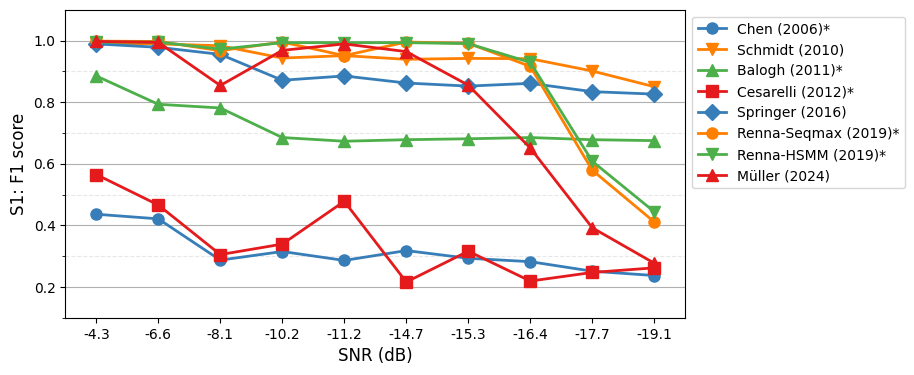

In [133]:
from itertools import cycle
names = [m.name for m in methods]
# markers = ["o","v","^","s","D","x","*","P"]

markers = cycle(["o","v","^","s","D"])
noise_names = ["-4.3","-6.6","-8.1","-10.2","-11.2","-14.7","-15.3","-16.4","-17.7","-19.1"]

plt.figure(figsize=(8,4))
lines = custom_lines()

for nl,name in zip(noise_levels_F1,names):
    style, color = next(lines)
    marker = next(markers)
    plt.plot(nl,color=color,linewidth=2,marker=marker,label=name,markersize=8)

plt.ylim((0.1,1.1))
plt.yticks(ticks=np.arange(0.1,1,0.2),minor=True)
plt.xlim((-0.5,9.5))
plt.xticks(ticks=np.arange(len(noise_names)),labels=noise_names)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.grid(True,axis="y",which="both")
plt.xlabel("SNR (dB)",fontsize="large")
plt.ylabel("S1: F1 score",fontsize="large")
ax = plt.gca()
ax.grid(which="minor",alpha=0.3,linestyle="--")
plt.savefig("noise_f1.pdf",bbox_inches="tight")
plt.show()